# Linear Structure in Latent Space — Visual Experiments

> **Goal:** *Feel* what "the model encodes concepts as linear directions" means — and see exactly where that linearity helps and where it breaks.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Latent Direction Hypothesis** | Does one factor of variation map to one straight, isolated axis (a "slider")? |
| 2 | **Latent Arithmetic** | Why does $z_{king} - z_{man} + z_{woman} \approx z_{queen}$ work? |
| 3 | **Regularization vs Identity** | How does regularization stop an over-parameterized AE from memorizing? |
| 4 | **Anisotropy / Cone Collapse** | What does representation degeneration look like, and why does cosine similarity explode? |
| 5 | **Lerp vs Slerp** | Why does straight-line interpolation fail on a curved manifold? |

---
**Linked theory:** [research/01-linear-structure.md](../research/01-linear-structure.md)  ·  **Chạy:** `uv run jupyter lab` từ thư mục `latent-anything-theory/` (cần các package trong `pyproject.toml`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete. NumPy:', np.__version__)

Setup complete. NumPy: 2.4.6


---
## Experiment 1: The Latent Direction Hypothesis — one factor, one axis

**Question:** If a model has truly "flattened the manifold", does moving along a *single straight direction* in latent space change *exactly one* factor of variation while leaving the others untouched?

The hypothesis from the research file: an over-parameterized model, forced to compress, encodes each **factor of variation** (smile, age, ...) as a **linearly accessible direction** — a slider. We simulate a tiny "decoder" that renders a cartoon face from a 2D latent code $z = [\text{smile},\, \text{age}]$, then walk along each axis independently.

In [2]:
np.random.seed(1)

# A latent code z = [smile, age]; a hand-built 'decoder' renders a cartoon face.
# Latent Direction Hypothesis: one factor of variation == one linear axis.
smile_axis = np.array([1.0, 0.0])   # direction that should control ONLY the smile
age_axis   = np.array([0.0, 1.0])   # direction that should control ONLY the age

z_center = np.array([0.0, 0.5])     # neutral expression, middle age
slider   = np.linspace(-1.0, 1.0, 5)


def draw_face(ax, smile, age):
    """Minimal differentiable-in-spirit 'decoder': latent -> pixels (cartoon)."""
    age = float(np.clip(age, 0.0, 1.0))
    skin = np.array([1.00, 0.83, 0.66]) * (1 - age) + np.array([0.72, 0.72, 0.74]) * age
    ax.add_patch(plt.Circle((0, 0), 1.0, facecolor=skin, edgecolor='black', lw=1.6))
    # eyes
    for ex in (-0.38, 0.38):
        ax.add_patch(plt.Circle((ex, 0.28), 0.11, facecolor='white', edgecolor='black', lw=1.2))
        ax.add_patch(plt.Circle((ex, 0.28), 0.045, facecolor='black'))
    # mouth: a parabola whose corners rise (smile) or fall (frown); pivots at the centre
    xs = np.linspace(-0.45, 0.45, 60)
    ys = -0.45 + smile * 1.1 * xs**2
    ax.plot(xs, ys, color='#a83232', lw=2.6, solid_capstyle='round')
    # wrinkles appear only for older ages -> a *secondary* visible effect of the age axis
    if age > 0.5:
        for wx in (-0.6, 0.6):
            ax.plot([wx - 0.05, wx + 0.05], [-0.02, -0.02], color='gray', lw=1.0)
        ax.plot(xs * 0.6, 0.66 + 0.03 * np.cos(xs * 14), color='gray', lw=0.8)
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.35)
    ax.set_aspect('equal')
    ax.axis('off')


print('Smile axis:', smile_axis, '| Age axis:', age_axis)
print('Slider positions:', np.round(slider, 2))

Smile axis: [1. 0.] | Age axis: [0. 1.]
Slider positions: [-1.  -0.5  0.   0.5  1. ]


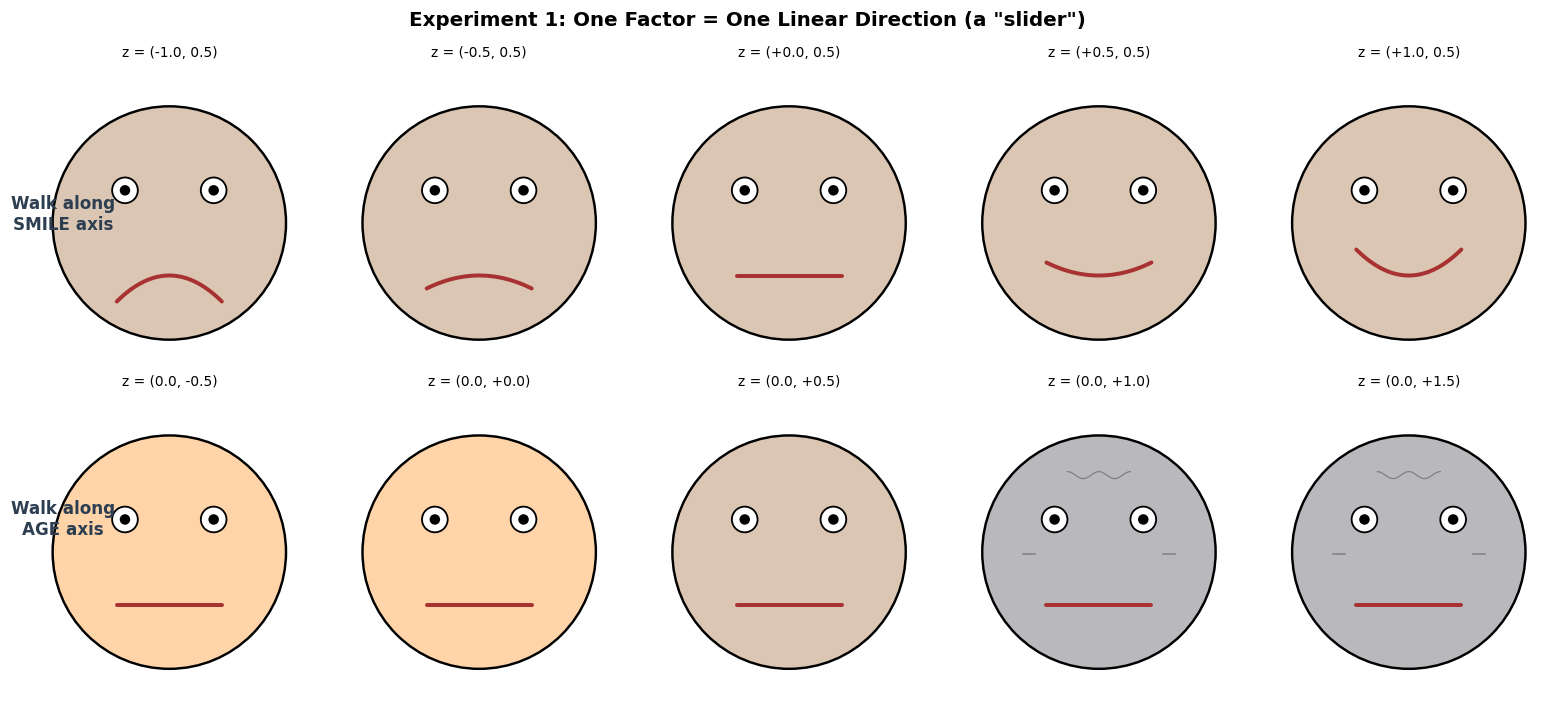

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6.6))
fig.suptitle('Experiment 1: One Factor = One Linear Direction (a "slider")',
             fontsize=13, fontweight='bold')

# Row 0: walk along the SMILE axis (age held fixed)
for j, t in enumerate(slider):
    z = z_center + t * smile_axis
    draw_face(axes[0, j], smile=z[0], age=z[1])
    axes[0, j].set_title(f'z = ({z[0]:+.1f}, {z[1]:.1f})', fontsize=9)

# Row 1: walk along the AGE axis (smile held fixed)
for j, t in enumerate(slider):
    z = z_center + t * age_axis
    draw_face(axes[1, j], smile=z[0], age=z[1])
    axes[1, j].set_title(f'z = ({z[0]:.1f}, {z[1]:+.1f})', fontsize=9)

fig.text(0.085, 0.70, 'Walk along\nSMILE axis', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#2c3e50')
fig.text(0.085, 0.28, 'Walk along\nAGE axis', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#2c3e50')

plt.tight_layout(rect=(0.05, 0, 1, 1))
plt.show()

### What you see

1. **What the plot shows:** Walking left→right along the **smile axis** (top row) morphs the mouth from a deep frown to a wide smile — while the skin tone and wrinkles (the *age* attribute) stay frozen. Walking along the **age axis** (bottom row) greys the skin and adds wrinkles while the mouth stays neutral. Each row is a *straight line* in latent space, yet only one attribute moves.

2. **Why it looks this way:** We deliberately built the decoder so that the two factors map to orthogonal coordinate axes. This is the *idealized* version of what the Latent Direction Hypothesis claims a well-trained, regularized model approximates: the messy, entangled pixel space is "flattened" so that semantically meaningful changes become **parallel translations** along fixed vectors.

3. **Key takeaway:** When a factor of variation is encoded as a linear direction, manipulating it becomes a *slider* — a single vector you add to $z$. This linearity is the entire foundation that the next experiments build on (and later stress-test).

---
## Experiment 2: Latent Arithmetic — why $king - man + woman \approx queen$

**Question:** If concepts are linear directions, can we do *algebra* on meaning? And is the "gender" delta really the **same vector** everywhere (a Causal Delta Embedding)?

The research file's key consequence: because logical/semantic relations become **parallel geometric translations**, vector arithmetic isolates a single attribute change without disturbing the others. We embed four word-pairs in a 2D space built from two latent directions — a *gender* axis and a *royalty* axis — then test the famous analogy.

In [4]:
np.random.seed(2)

# Two semantic factors as fixed linear directions in a 2D 'embedding' space.
gender_dir  = np.array([3.0, 0.4])   # male  -> female translation
royalty_dir = np.array([0.6, 2.6])   # common -> royal  translation

# Male anchor words placed at different semantic positions...
male_anchors = {
    'man':   np.array([0.0,  0.0]),
    'king':  royalty_dir.copy(),       # = man + royalty
    'uncle': np.array([-1.2, 2.4]),
    'actor': np.array([3.3, -1.6]),
}
female_of = {'man': 'woman', 'king': 'queen', 'uncle': 'aunt', 'actor': 'actress'}

words = {}
for name, pos in male_anchors.items():
    words[name] = pos + 0.10 * np.random.randn(2)
# ...each female word = its male anchor + the SAME gender direction (+ noise)
for m, f in female_of.items():
    words[f] = words[m] + gender_dir + 0.10 * np.random.randn(2)

# The analogy: king - man + woman  =?  queen
pred = words['king'] - words['man'] + words['woman']

dists = {w: float(np.linalg.norm(pred - p)) for w, p in words.items()}
ranked = sorted(dists, key=dists.get)
print('king - man + woman lands at:', np.round(pred, 2))
print('\nNearest words to the result:')
for w in ranked[:4]:
    print(f'  {w:8s}  distance = {dists[w]:.3f}')

king - man + woman lands at: [3.28 3.07]

Nearest words to the result:
  queen     distance = 0.358
  aunt      distance = 1.721
  woman     distance = 2.803
  king      distance = 2.911


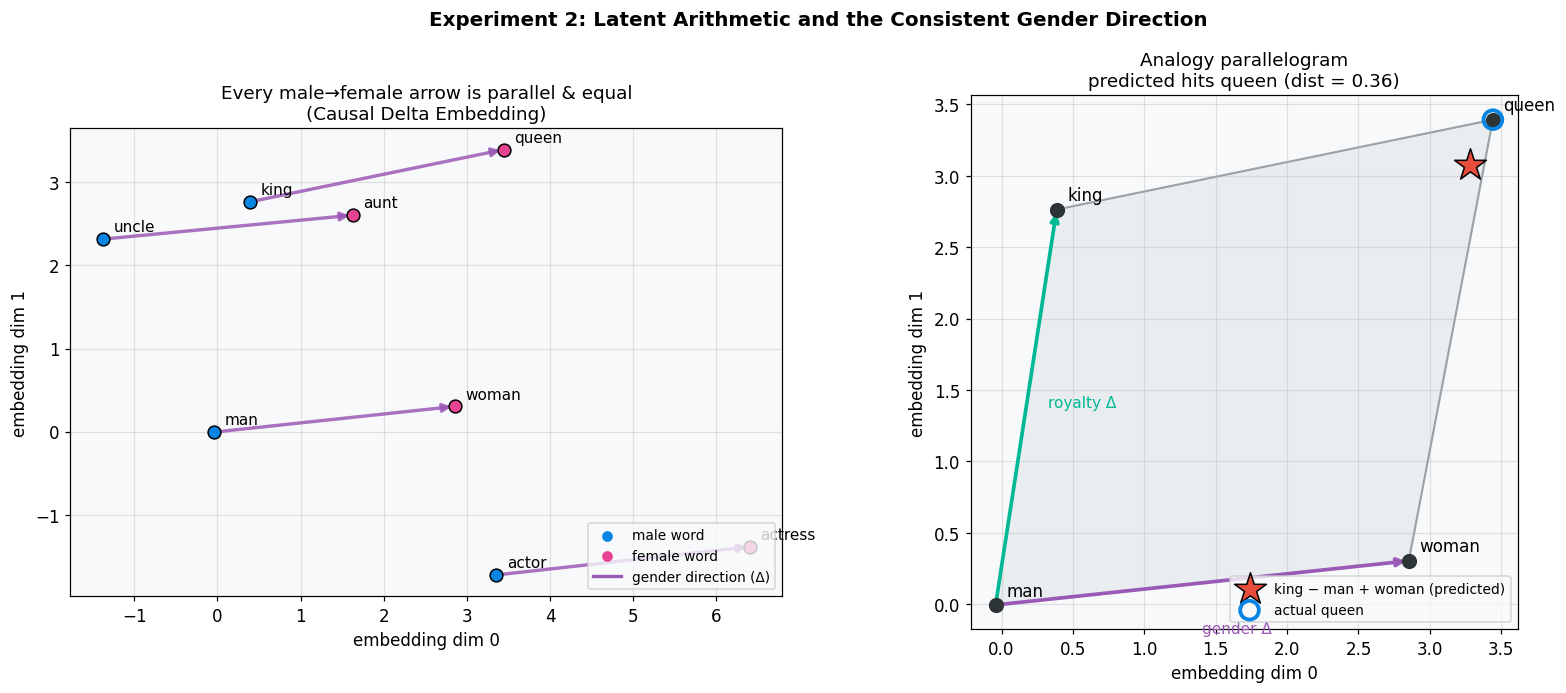

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.4))
fig.suptitle('Experiment 2: Latent Arithmetic and the Consistent Gender Direction',
             fontsize=13, fontweight='bold')

# --- Left: every male->female arrow is the SAME translation -> parallel arrows ---
ax1 = axes[0]
for m, f in female_of.items():
    ax1.annotate('', xy=words[f], xytext=words[m],
                 arrowprops=dict(arrowstyle='-|>', color='#9b59b6', lw=2.2, alpha=0.85))
for name, p in words.items():
    is_f = name in female_of.values()
    ax1.scatter(*p, s=70, zorder=5,
                color='#e84393' if is_f else '#0984e3', edgecolors='black')
    ax1.annotate(name, p, textcoords='offset points', xytext=(7, 5), fontsize=10)
ax1.scatter([], [], color='#0984e3', label='male word')
ax1.scatter([], [], color='#e84393', label='female word')
ax1.plot([], [], color='#9b59b6', lw=2.2, label='gender direction (Δ)')
ax1.set_xlabel('embedding dim 0')
ax1.set_ylabel('embedding dim 1')
ax1.set_title('Every male\u2192female arrow is parallel & equal\n(Causal Delta Embedding)')
ax1.legend(fontsize=9, loc='lower right')
ax1.set_aspect('equal')

# --- Right: the analogy parallelogram ---
ax2 = axes[1]
quad = np.array([words['man'], words['king'], words['queen'], words['woman']])
ax2.add_patch(mpatches.Polygon(quad, closed=True, fill=True,
                               facecolor='#dfe6e9', edgecolor='#636e72', lw=1.4, alpha=0.6))
for w in ['man', 'king', 'queen', 'woman']:
    ax2.scatter(*words[w], s=80, color='#2d3436', zorder=5)
    ax2.annotate(w, words[w], textcoords='offset points', xytext=(7, 6), fontsize=11)
# the two translations that build the analogy
ax2.annotate('', xy=words['king'], xytext=words['man'],
             arrowprops=dict(arrowstyle='-|>', color='#00b894', lw=2.4))
ax2.annotate('', xy=words['woman'], xytext=words['man'],
             arrowprops=dict(arrowstyle='-|>', color='#9b59b6', lw=2.4))
ax2.text(*(0.5 * (words['man'] + words['king']) + np.array([0.15, 0.0])),
         'royalty Δ', color='#00b894', fontsize=10)
ax2.text(*(0.5 * (words['man'] + words['woman']) + np.array([0.0, -0.35])),
         'gender Δ', color='#9b59b6', fontsize=10)
ax2.scatter(*pred, marker='*', s=480, color='#e74c3c', edgecolors='black', zorder=10,
            label='king \u2212 man + woman (predicted)')
ax2.scatter(*words['queen'], s=150, facecolors='none', edgecolors='#0984e3', lw=2.5,
            zorder=11, label='actual queen')
ax2.set_xlabel('embedding dim 0')
ax2.set_ylabel('embedding dim 1')
ax2.set_title(f"Analogy parallelogram\npredicted hits queen (dist = {dists['queen']:.2f})")
ax2.legend(fontsize=9, loc='lower right')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** On the left, the four male→female arrows (man→woman, king→queen, uncle→aunt, actor→actress) are all **parallel and the same length** — a single "gender" translation vector. On the right, starting from *man*, adding the *royalty* Δ and the *gender* Δ closes a parallelogram whose fourth corner — the red star $king - man + woman$ — lands essentially on the actual *queen* (open blue circle), much closer than to any other word.

2. **Why it looks this way:** Because the embedding was constructed from two fixed linear directions, the relation "make this word royal" and "make this word female" are *position-independent* translations. Subtracting $man$ removes the shared base and the male-ness; adding $woman$ re-injects female-ness; the royalty already carried by $king$ survives untouched. This is the **Causal Delta Embedding** idea: an intervention is one isolated difference vector.

3. **Key takeaway:** Vector arithmetic "works" precisely *because* attributes are parallel linear directions. The analogy is geometry, not magic — and it only holds as far as the linear-direction approximation holds.

---
## Experiment 3: Regularization vs the Identity Function

**Question:** An over-parameterized autoencoder *can* just copy its input (learn the identity function) and learn nothing useful. What does regularization actually do to prevent this — and how does that create clean linear directions?

The research file: without regularization a large model risks learning $f(x)=x$, extracting no factors. Penalties — weight decay, sparsity, **input noise (denoising)** — force the latent space to become compact and to align with the true factors of variation. We compare a plain linear AE (which collapses to identity) against a denoising AE, on data that truly lives on a 2D subspace inside 8D.

In [6]:
np.random.seed(3)

D, k_true, n = 8, 2, 600
# True factor basis: a 2D subspace inside 8D ambient space.
Q, _ = np.linalg.qr(np.random.randn(D, D))
A = Q[:, :k_true]                                   # (D, 2) true factor directions
S = np.random.randn(n, k_true) * np.array([2.5, 1.3])
X_clean = S @ A.T                                   # data on the 2D subspace
sigma_noise = 0.5
X = X_clean + sigma_noise * np.random.randn(n, D)   # observed: signal + off-subspace noise

Xc, Xcl = X.T, X_clean.T                            # columns = samples (D, n)

# Plain over-parameterized AE: min ||X - W X|| over a free DxD W  ->  W = I (memorizes noise too)
W_plain = np.eye(D)
# Denoising / regularized AE: learn noisy -> clean. Suppresses the noise sub-space.
W_denoise = Xcl @ Xc.T @ np.linalg.inv(Xc @ Xc.T + 1e-6 * np.eye(D))


def participation_ratio(svals):
    s2 = svals**2
    return float(s2.sum()**2 / np.sum(s2**2))      # 'effective rank'


sv_plain = np.linalg.svd(W_plain, compute_uv=False)
sv_den = np.linalg.svd(W_denoise, compute_uv=False)

P_sig = A @ A.T                                     # projector onto the signal subspace


def noise_fraction(W):
    recon = W @ Xc
    noise_part = recon - P_sig @ recon
    return float((noise_part**2).sum() / (recon**2).sum())


pr_plain, pr_den = participation_ratio(sv_plain), participation_ratio(sv_den)
print('Effective rank (participation ratio of W):')
print(f'  Plain AE  (identity):    {pr_plain:4.2f}   uses all {D} dims  -> memorizes')
print(f'  Denoising (regularized): {pr_den:4.2f}   ~= {k_true} true factors')
print('\nFraction of reconstruction energy spent on NOISE directions:')
print(f'  Plain AE:    {noise_fraction(W_plain):.3f}   (keeps the noise)')
print(f'  Denoising:   {noise_fraction(W_denoise):.3f}   (discards the noise)')

Effective rank (participation ratio of W):
  Plain AE  (identity):    8.00   uses all 8 dims  -> memorizes
  Denoising (regularized): 1.99   ~= 2 true factors

Fraction of reconstruction energy spent on NOISE directions:
  Plain AE:    0.147   (keeps the noise)
  Denoising:   0.000   (discards the noise)


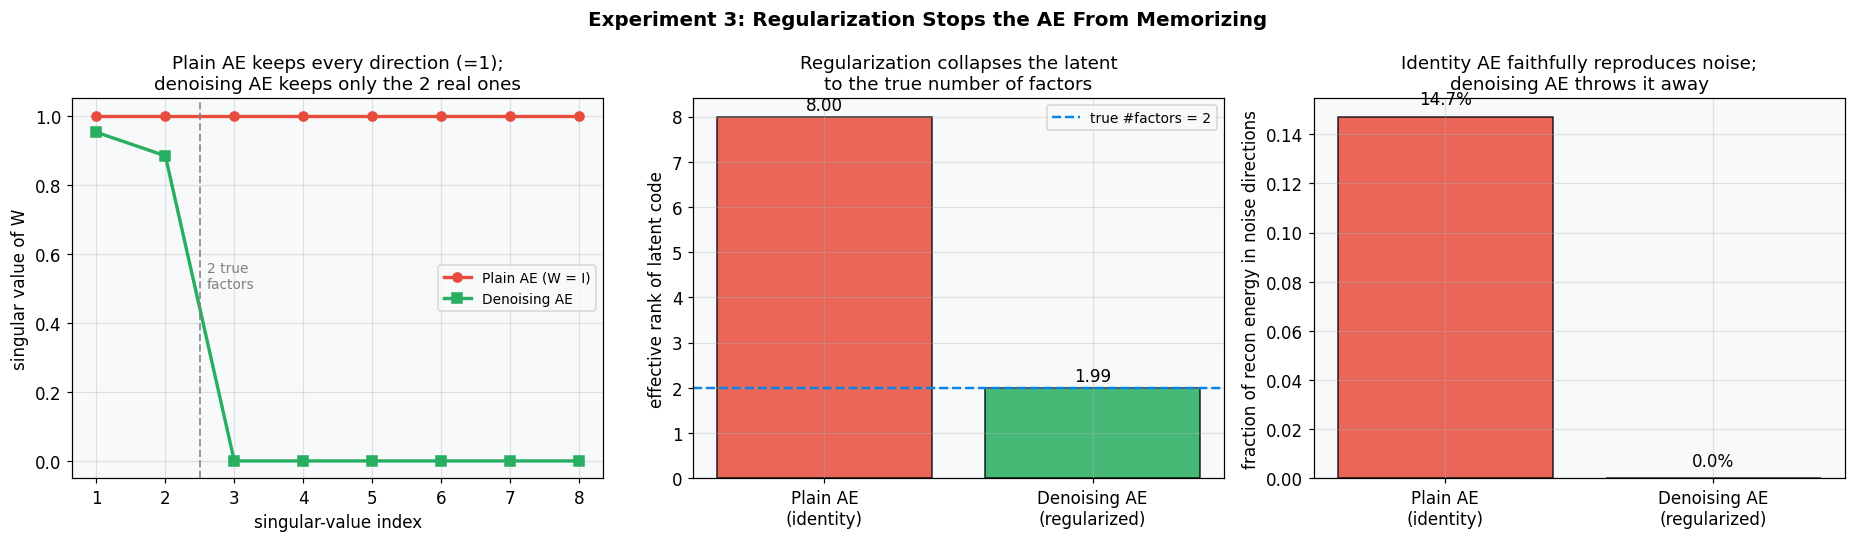

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Experiment 3: Regularization Stops the AE From Memorizing',
             fontsize=13, fontweight='bold')

# --- Left: singular-value spectra of the learned operator W ---
ax1 = axes[0]
idx = np.arange(1, D + 1)
ax1.plot(idx, sv_plain, 'o-', color='#e74c3c', lw=2.2, label='Plain AE (W = I)')
ax1.plot(idx, sv_den, 's-', color='#27ae60', lw=2.2, label='Denoising AE')
ax1.axvline(k_true + 0.5, color='gray', ls='--', lw=1.3, alpha=0.8)
ax1.text(k_true + 0.6, 0.5, f'{k_true} true\nfactors', fontsize=9, color='gray')
ax1.set_xlabel('singular-value index')
ax1.set_ylabel('singular value of W')
ax1.set_title('Plain AE keeps every direction (=1);\ndenoising AE keeps only the 2 real ones')
ax1.legend(fontsize=9)

# --- Middle: effective rank (participation ratio) ---
ax2 = axes[1]
bars = ax2.bar(['Plain AE\n(identity)', 'Denoising AE\n(regularized)'],
               [pr_plain, pr_den], color=['#e74c3c', '#27ae60'],
               edgecolor='black', alpha=0.85)
ax2.axhline(k_true, color='#0984e3', ls='--', lw=1.6, label=f'true #factors = {k_true}')
for b, v in zip(bars, [pr_plain, pr_den]):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.15, f'{v:.2f}', ha='center', fontsize=11)
ax2.set_ylabel('effective rank of latent code')
ax2.set_title('Regularization collapses the latent\nto the true number of factors')
ax2.legend(fontsize=9)

# --- Right: how much reconstruction energy goes into NOISE ---
ax3 = axes[2]
nf = [noise_fraction(W_plain), noise_fraction(W_denoise)]
bars = ax3.bar(['Plain AE\n(identity)', 'Denoising AE\n(regularized)'],
               nf, color=['#e74c3c', '#27ae60'], edgecolor='black', alpha=0.85)
for b, v in zip(bars, nf):
    ax3.text(b.get_x() + b.get_width() / 2, v + 0.005, f'{v:.1%}', ha='center', fontsize=11)
ax3.set_ylabel('fraction of recon energy in noise directions')
ax3.set_title('Identity AE faithfully reproduces noise;\ndenoising AE throws it away')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The plain AE's operator $W$ has **all 8 singular values equal to 1** (left, red) — it is the identity, so its effective rank is the full 8 (middle) and it reproduces 100% of the noise (right). The denoising AE keeps only **two** large singular values (the real factors) and shrinks the rest, giving an effective rank ≈ 2 and reproducing almost none of the off-subspace noise.

2. **Why it looks this way:** With no constraint, copying the input is a *perfect* (zero-error) solution — so an over-parameterized AE happily learns $W=I$ and extracts nothing. Forcing it to map a *noisy* input back to the *clean* signal makes the identity solution suboptimal: the operator must project onto the directions where signal actually lives (the top-2 subspace) and suppress the noise directions. Weight decay and sparsity penalties act the same way — they make "use every dimension equally" expensive.

3. **Key takeaway:** Regularization is what turns a memorizing copier into a feature extractor. By making the latent code **low-rank and aligned with the factors of variation**, it is the precondition for the linear directions (and the arithmetic of Experiment 2) to exist at all.

---
## Experiment 4: Anisotropy — when representations collapse into a narrow cone

**Question:** What does **representation degeneration** look like geometrically, and why does it make *unrelated* vectors look highly similar?

The research file's negative consequence: in models like Transformers, self-attention (a contraction) plus weight tying squeeze embeddings into a **narrow cone** instead of spreading them isotropically. The damage: inflated cosine similarity between unrelated vectors and a reduced *effective* dimensionality. We compare a healthy isotropic cloud against a degenerate cone.

In [8]:
np.random.seed(4)

D, n = 64, 800
# Healthy: isotropic Gaussian -> spreads in all directions.
Z_iso = np.random.randn(n, D)

# Degenerate: every vector hugs one shared mean direction -> a narrow cone.
mean_dir = np.random.randn(D)
mean_dir /= np.linalg.norm(mean_dir)
mags = 2.0 + 0.5 * np.random.randn(n)
Z_aniso = np.outer(mags, mean_dir) + 0.25 * np.random.randn(n, D)


def cosine_pairs(Z, m=5000):
    i = np.random.randint(0, len(Z), m)
    j = np.random.randint(0, len(Z), m)
    keep = i != j
    a, b = Z[i[keep]], Z[j[keep]]
    return (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1))


def effective_dim(Z):
    sv = np.linalg.svd(Z, compute_uv=False)        # uncentered: captures the shared offset
    s2 = sv**2
    return float(s2.sum()**2 / np.sum(s2**2))


cs_iso, cs_an = cosine_pairs(Z_iso), cosine_pairs(Z_aniso)
ed_iso, ed_an = effective_dim(Z_iso), effective_dim(Z_aniso)

# Shared 2D viewing plane: axis 0 = the cone's mean direction, axis 1 = orthogonal.
tmp = np.random.randn(D)
u2 = tmp - (tmp @ mean_dir) * mean_dir
u2 /= np.linalg.norm(u2)
proj = lambda Z: np.c_[Z @ mean_dir, Z @ u2]
P_iso, P_an = proj(Z_iso), proj(Z_aniso)

print(f'Mean |cosine| of unrelated pairs:  isotropic={np.abs(cs_iso).mean():.3f}   '
      f'anisotropic={np.abs(cs_an).mean():.3f}')
print(f'Effective dimensionality (of {D}): isotropic={ed_iso:.1f}        '
      f'anisotropic={ed_an:.1f}')

Mean |cosine| of unrelated pairs:  isotropic=0.100   anisotropic=0.480
Effective dimensionality (of 64): isotropic=59.2        anisotropic=3.6


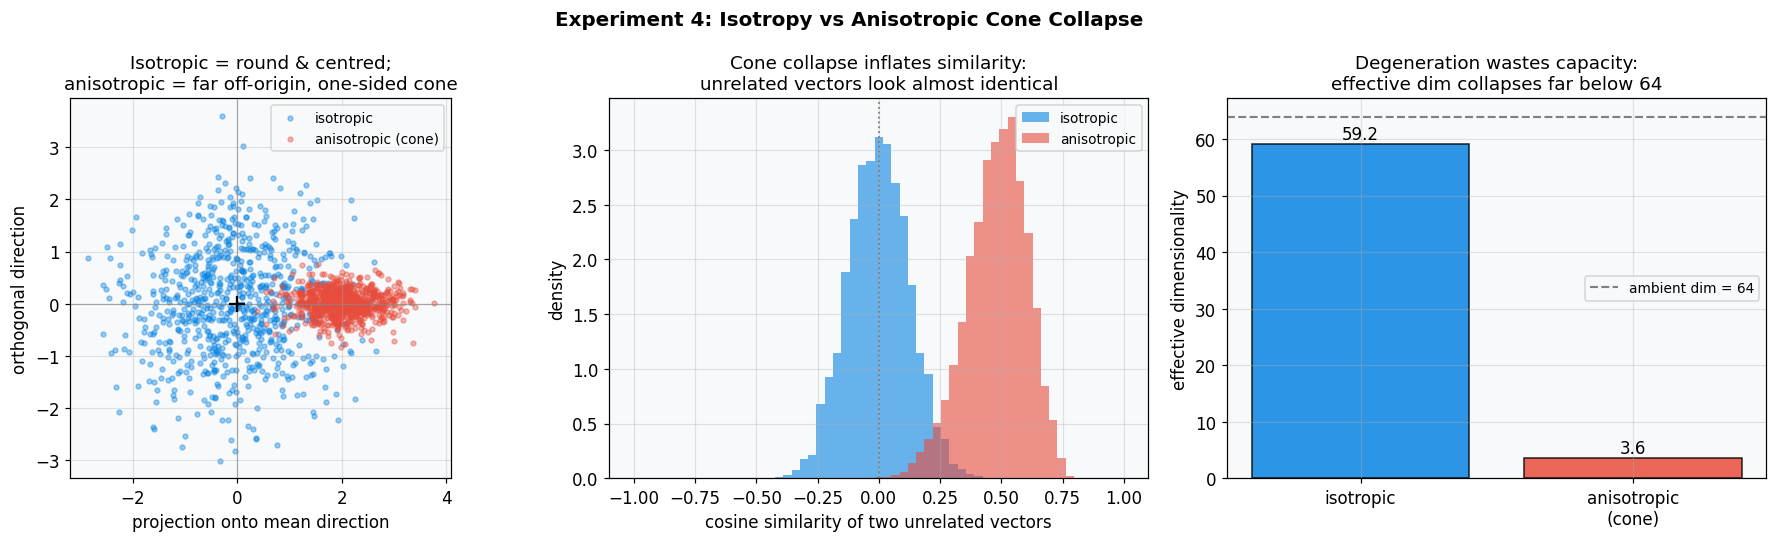

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Experiment 4: Isotropy vs Anisotropic Cone Collapse',
             fontsize=13, fontweight='bold')

# --- Left: the two clouds on a shared plane (mean-direction vs orthogonal) ---
ax1 = axes[0]
ax1.scatter(P_iso[:, 0], P_iso[:, 1], s=10, alpha=0.4, color='#0984e3', label='isotropic')
ax1.scatter(P_an[:, 0], P_an[:, 1], s=10, alpha=0.4, color='#e74c3c', label='anisotropic (cone)')
ax1.axhline(0, color='gray', lw=0.8, alpha=0.6)
ax1.axvline(0, color='gray', lw=0.8, alpha=0.6)
ax1.scatter(0, 0, marker='+', s=120, color='black', zorder=6)
ax1.set_xlabel('projection onto mean direction')
ax1.set_ylabel('orthogonal direction')
ax1.set_title('Isotropic = round & centred;\nanisotropic = far off-origin, one-sided cone')
ax1.legend(fontsize=9)
ax1.set_aspect('equal')

# --- Middle: cosine similarity of unrelated pairs ---
ax2 = axes[1]
bins = np.linspace(-1, 1, 60)
ax2.hist(cs_iso, bins=bins, alpha=0.6, color='#0984e3', density=True, label='isotropic')
ax2.hist(cs_an, bins=bins, alpha=0.6, color='#e74c3c', density=True, label='anisotropic')
ax2.axvline(0, color='gray', ls=':', lw=1.2)
ax2.set_xlabel('cosine similarity of two unrelated vectors')
ax2.set_ylabel('density')
ax2.set_title('Cone collapse inflates similarity:\nunrelated vectors look almost identical')
ax2.legend(fontsize=9)

# --- Right: effective dimensionality ---
ax3 = axes[2]
bars = ax3.bar(['isotropic', 'anisotropic\n(cone)'], [ed_iso, ed_an],
               color=['#0984e3', '#e74c3c'], edgecolor='black', alpha=0.85)
ax3.axhline(D, color='gray', ls='--', lw=1.4, label=f'ambient dim = {D}')
for b, v in zip(bars, [ed_iso, ed_an]):
    ax3.text(b.get_x() + b.get_width() / 2, v + 0.8, f'{v:.1f}', ha='center', fontsize=11)
ax3.set_ylabel('effective dimensionality')
ax3.set_title('Degeneration wastes capacity:\neffective dim collapses far below 64')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Projected onto a shared plane (left), the isotropic cloud is a round blob centred at the origin, while the anisotropic cloud sits far out along the mean direction as a thin, **one-sided sliver** — a cone. The middle histogram is the smoking gun: cosine similarities of *unrelated* vectors are centred at 0 for the healthy cloud but pile up near **+1** for the cone. The right bars show the cone's effective dimensionality collapses from 64 down to a handful.

2. **Why it looks this way:** When every vector carries a large shared component along one mean direction, the angle between any two of them is small — so cosine similarity is high regardless of their actual content. That shared offset also means one singular value dominates, crushing the participation ratio (effective rank). This is exactly the **representation degeneration** the research file attributes to contraction effects and weight tying.

3. **Key takeaway:** Anisotropy is the *dark side* of linear structure: the geometry is still "linear", but squeezed so badly that distances and similarities become uninformative. It motivates isotropy regularizers / whitening — and is why raw cosine similarity on degenerate embeddings can be misleading.

---
## Experiment 5: Lerp vs Slerp — when the straight line leaves the manifold

**Question:** Two valid latent points lie on a curved manifold. If we interpolate between them along a **straight Euclidean line (Lerp)**, does the path stay on the data manifold — or cut through empty, off-manifold space?

The research file's final consequence: even when the model tries to flatten things, the decoder reshapes the latent into a **curved Riemannian manifold**. A straight chord between distant points slices through low-density "off-manifold" regions where the norm is depressed, producing blurry/distorted decodes. The fix: **Slerp** (spherical) or a geodesic that follows the data. We make the manifold an arc and compare both paths.

In [10]:
np.random.seed(5)

# A 1D curved manifold: an arc of a circle (data lives only on this thin band).
n = 400
theta = np.linspace(0.18 * np.pi, 0.82 * np.pi, n)
manifold = np.c_[np.cos(theta), np.sin(theta)] + 0.02 * np.random.randn(n, 2)

# Two distant endpoints, both on the arc.
a = np.array([np.cos(0.22 * np.pi), np.sin(0.22 * np.pi)])
b = np.array([np.cos(0.78 * np.pi), np.sin(0.78 * np.pi)])

ts = np.linspace(0, 1, 50)
lerp = (1 - ts)[:, None] * a + ts[:, None] * b      # straight-line interpolation


def slerp(a, b, ts):
    a_n, b_n = a / np.linalg.norm(a), b / np.linalg.norm(b)
    omega = np.arccos(np.clip(a_n @ b_n, -1, 1))
    ra, rb = np.linalg.norm(a), np.linalg.norm(b)
    out = []
    for t in ts:
        dir_t = (np.sin((1 - t) * omega) * a_n + np.sin(t * omega) * b_n) / np.sin(omega)
        out.append(dir_t * ((1 - t) * ra + t * rb))
    return np.array(out)


sl = slerp(a, b, ts)


def dist_to_manifold(path):
    d = np.sqrt(((path[:, None, :] - manifold[None, :, :]) ** 2).sum(-1))
    return d.min(1)


d_lerp, d_sl = dist_to_manifold(lerp), dist_to_manifold(sl)
norm_lerp, norm_sl = np.linalg.norm(lerp, axis=1), np.linalg.norm(sl, axis=1)

print(f'Max off-manifold distance:  Lerp={d_lerp.max():.3f}   Slerp={d_sl.max():.3f}')
print(f'Norm at midpoint (t=0.5):   Lerp={norm_lerp[25]:.3f}   Slerp={norm_sl[25]:.3f}'
      f'   (manifold radius = 1.0)')

Max off-manifold distance:  Lerp=0.332   Slerp=0.020
Norm at midpoint (t=0.5):   Lerp=0.638   Slerp=1.000   (manifold radius = 1.0)


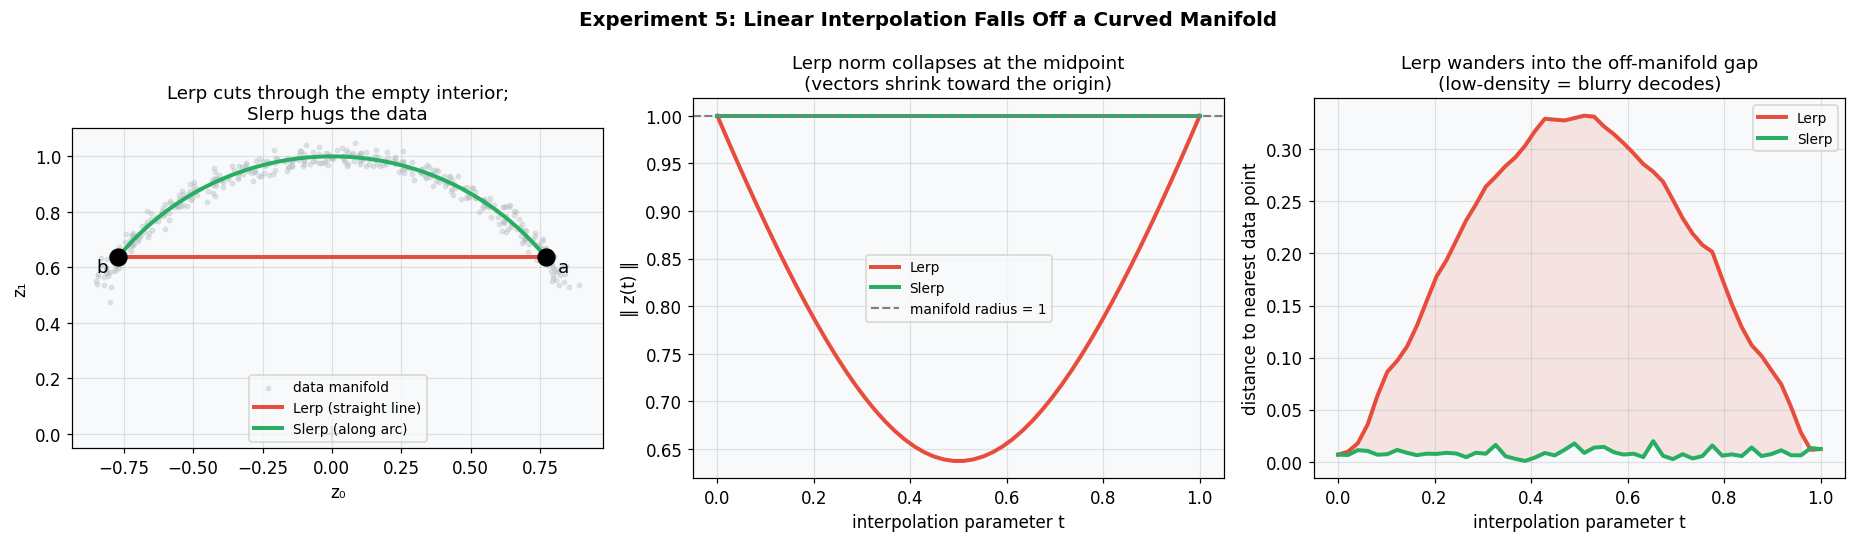

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Experiment 5: Linear Interpolation Falls Off a Curved Manifold',
             fontsize=13, fontweight='bold')

# --- Left: the manifold and the two paths ---
ax1 = axes[0]
ax1.scatter(manifold[:, 0], manifold[:, 1], s=8, alpha=0.35, color='#b2bec3',
            label='data manifold')
ax1.plot(lerp[:, 0], lerp[:, 1], '-', color='#e74c3c', lw=2.6, label='Lerp (straight line)')
ax1.plot(sl[:, 0], sl[:, 1], '-', color='#27ae60', lw=2.6, label='Slerp (along arc)')
ax1.scatter(*a, s=120, color='black', zorder=6)
ax1.scatter(*b, s=120, color='black', zorder=6)
ax1.annotate('a', a, textcoords='offset points', xytext=(8, -10), fontsize=12)
ax1.annotate('b', b, textcoords='offset points', xytext=(-14, -10), fontsize=12)
ax1.scatter(0, 0, marker='+', s=120, color='gray', zorder=5)
ax1.set_xlabel('z\u2080')
ax1.set_ylabel('z\u2081')
ax1.set_title('Lerp cuts through the empty interior;\nSlerp hugs the data')
ax1.legend(fontsize=9, loc='lower center')
ax1.set_aspect('equal')

# --- Middle: norm along the path ---
ax2 = axes[1]
ax2.plot(ts, norm_lerp, color='#e74c3c', lw=2.6, label='Lerp')
ax2.plot(ts, norm_sl, color='#27ae60', lw=2.6, label='Slerp')
ax2.axhline(1.0, color='gray', ls='--', lw=1.4, label='manifold radius = 1')
ax2.set_xlabel('interpolation parameter t')
ax2.set_ylabel('\u2016 z(t) \u2016')
ax2.set_title('Lerp norm collapses at the midpoint\n(vectors shrink toward the origin)')
ax2.legend(fontsize=9)

# --- Right: off-manifold distance along the path ---
ax3 = axes[2]
ax3.plot(ts, d_lerp, color='#e74c3c', lw=2.6, label='Lerp')
ax3.plot(ts, d_sl, color='#27ae60', lw=2.6, label='Slerp')
ax3.fill_between(ts, d_sl, d_lerp, where=(d_lerp > d_sl), color='#e74c3c', alpha=0.12)
ax3.set_xlabel('interpolation parameter t')
ax3.set_ylabel('distance to nearest data point')
ax3.set_title('Lerp wanders into the off-manifold gap\n(low-density = blurry decodes)')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The straight **Lerp** chord (red) dives through the empty interior of the arc, far from any real data, and its norm **sags toward the origin** at the midpoint (middle panel). The **Slerp** path (green) tracks the arc almost perfectly: its distance to the manifold stays near zero (right) and its norm stays near the manifold radius.

2. **Why it looks this way:** On a curved (Riemannian) manifold, the shortest Euclidean line between two distant points is a *chord*, which by definition leaves the curve. The mid-chord is closest to the centre, so its norm shrinks — exactly the "depressed-norm, off-manifold" region the research file warns about. Slerp interpolates the *angle* and the *radius* separately, so it stays on the spherical shell where the data lives.

3. **Key takeaway:** Linear structure is a *local* convenience, not a global guarantee. Over long distances the manifold's curvature bites: Lerp produces off-manifold, low-density codes (blurry/unrealistic decodes), and you need **Slerp or a geodesic** that respects the data geometry. This is the bridge to the geometry-and-structure topics that follow.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Latent Direction Hypothesis | A factor of variation can become a single straight axis — a "slider" that moves one attribute and leaves others fixed |
| 2. Latent Arithmetic | Analogies work because attributes are *parallel* linear translations; the delta vector is consistent (Causal Delta Embedding) |
| 3. Regularization vs Identity | Without regularization an over-parameterized AE collapses to the identity; denoising/weight-decay/sparsity force a low-rank, factor-aligned latent |
| 4. Anisotropy / Cone Collapse | Representation degeneration squeezes embeddings into a narrow cone, inflating cosine similarity and crushing effective dimensionality |
| 5. Lerp vs Slerp | A straight line between distant points leaves the curved manifold into low-density space; Slerp/geodesics stay on the data |

### Connection to the broader theory

These experiments trace the full arc of the *Latent Direction Hypothesis* — from its promise to its failure modes. Linearity is **created** by regularization (Exp 3), **exploited** by vector arithmetic and isolated sliders (Exp 1–2), but **degraded** by anisotropic collapse (Exp 4) and **broken** by manifold curvature over long distances (Exp 5). The last two failure modes are exactly why the project moves next into explicit geometric structure: pullback metrics, geodesics, and Riemannian treatments of latent space that replace the naive straight line with a curvature-aware path.